In [1]:
from pathlib import Path
import pandas as pd

table_pkl_dim2 = Path("~/t7ssd/classification_results_consistent_features/dim2/subsample_results_table.pkl")
df = pd.read_pickle(table_pkl_dim2)

In [2]:
group_cols = [
    "dimension",
    "sampling_strategy",
    "sample_size_per_dim",
    "n_instances_train",
    "n_runs_train",
    "n_feval_train",
]

# aggregate over the 5 folds
fold_agg_df = (
    df
    .groupby(group_cols, as_index=False)
    .agg(
        acc_mean=("accuracy_median", "mean"),
        acc_sd=("accuracy_median", "std"),
        acc_allruns_mean=("accuracy_allruns", "mean"),
        consistency_mean=("consistency", "mean"),
        cv_instance_median_mean=("cv_instance_median_mean", "first"),
        cv_instance_median_median=("cv_instance_median_median", "first"),
        cv_function_median_mean=("cv_function_median_mean", "first"),
        cv_function_median_median=("cv_function_median_median", "first"),
        # feature meta‑info (optional)
        # n_features=("n_features", "first"),
        # n_omitted_features=("n_omitted_features", "first"),
        # omitted_features=("omitted_features", "first"),
    )
)

In [3]:
df.columns


Index(['dimension', 'sampling_strategy', 'sample_size_per_dim',
       'n_instances_train', 'n_runs_train', 'n_feval_train', 'fold',
       'n_features', 'n_omitted_features', 'omitted_features',
       'cv_instance_median_mean', 'cv_instance_median_median',
       'cv_function_median_mean', 'cv_function_median_median',
       'cv_training_folds_median_mean', 'cv_training_folds_median_median',
       'accuracy_median', 'accuracy_allruns', 'consistency'],
      dtype='str')

In [4]:
pd.qcut(df["n_feval_train"], q=4).value_counts()

n_feval_train
(1199.999, 14400.0]    900
(14400.0, 36000.0]     850
(77700.0, 480000.0]    800
(36000.0, 77700.0]     650
Name: count, dtype: int64

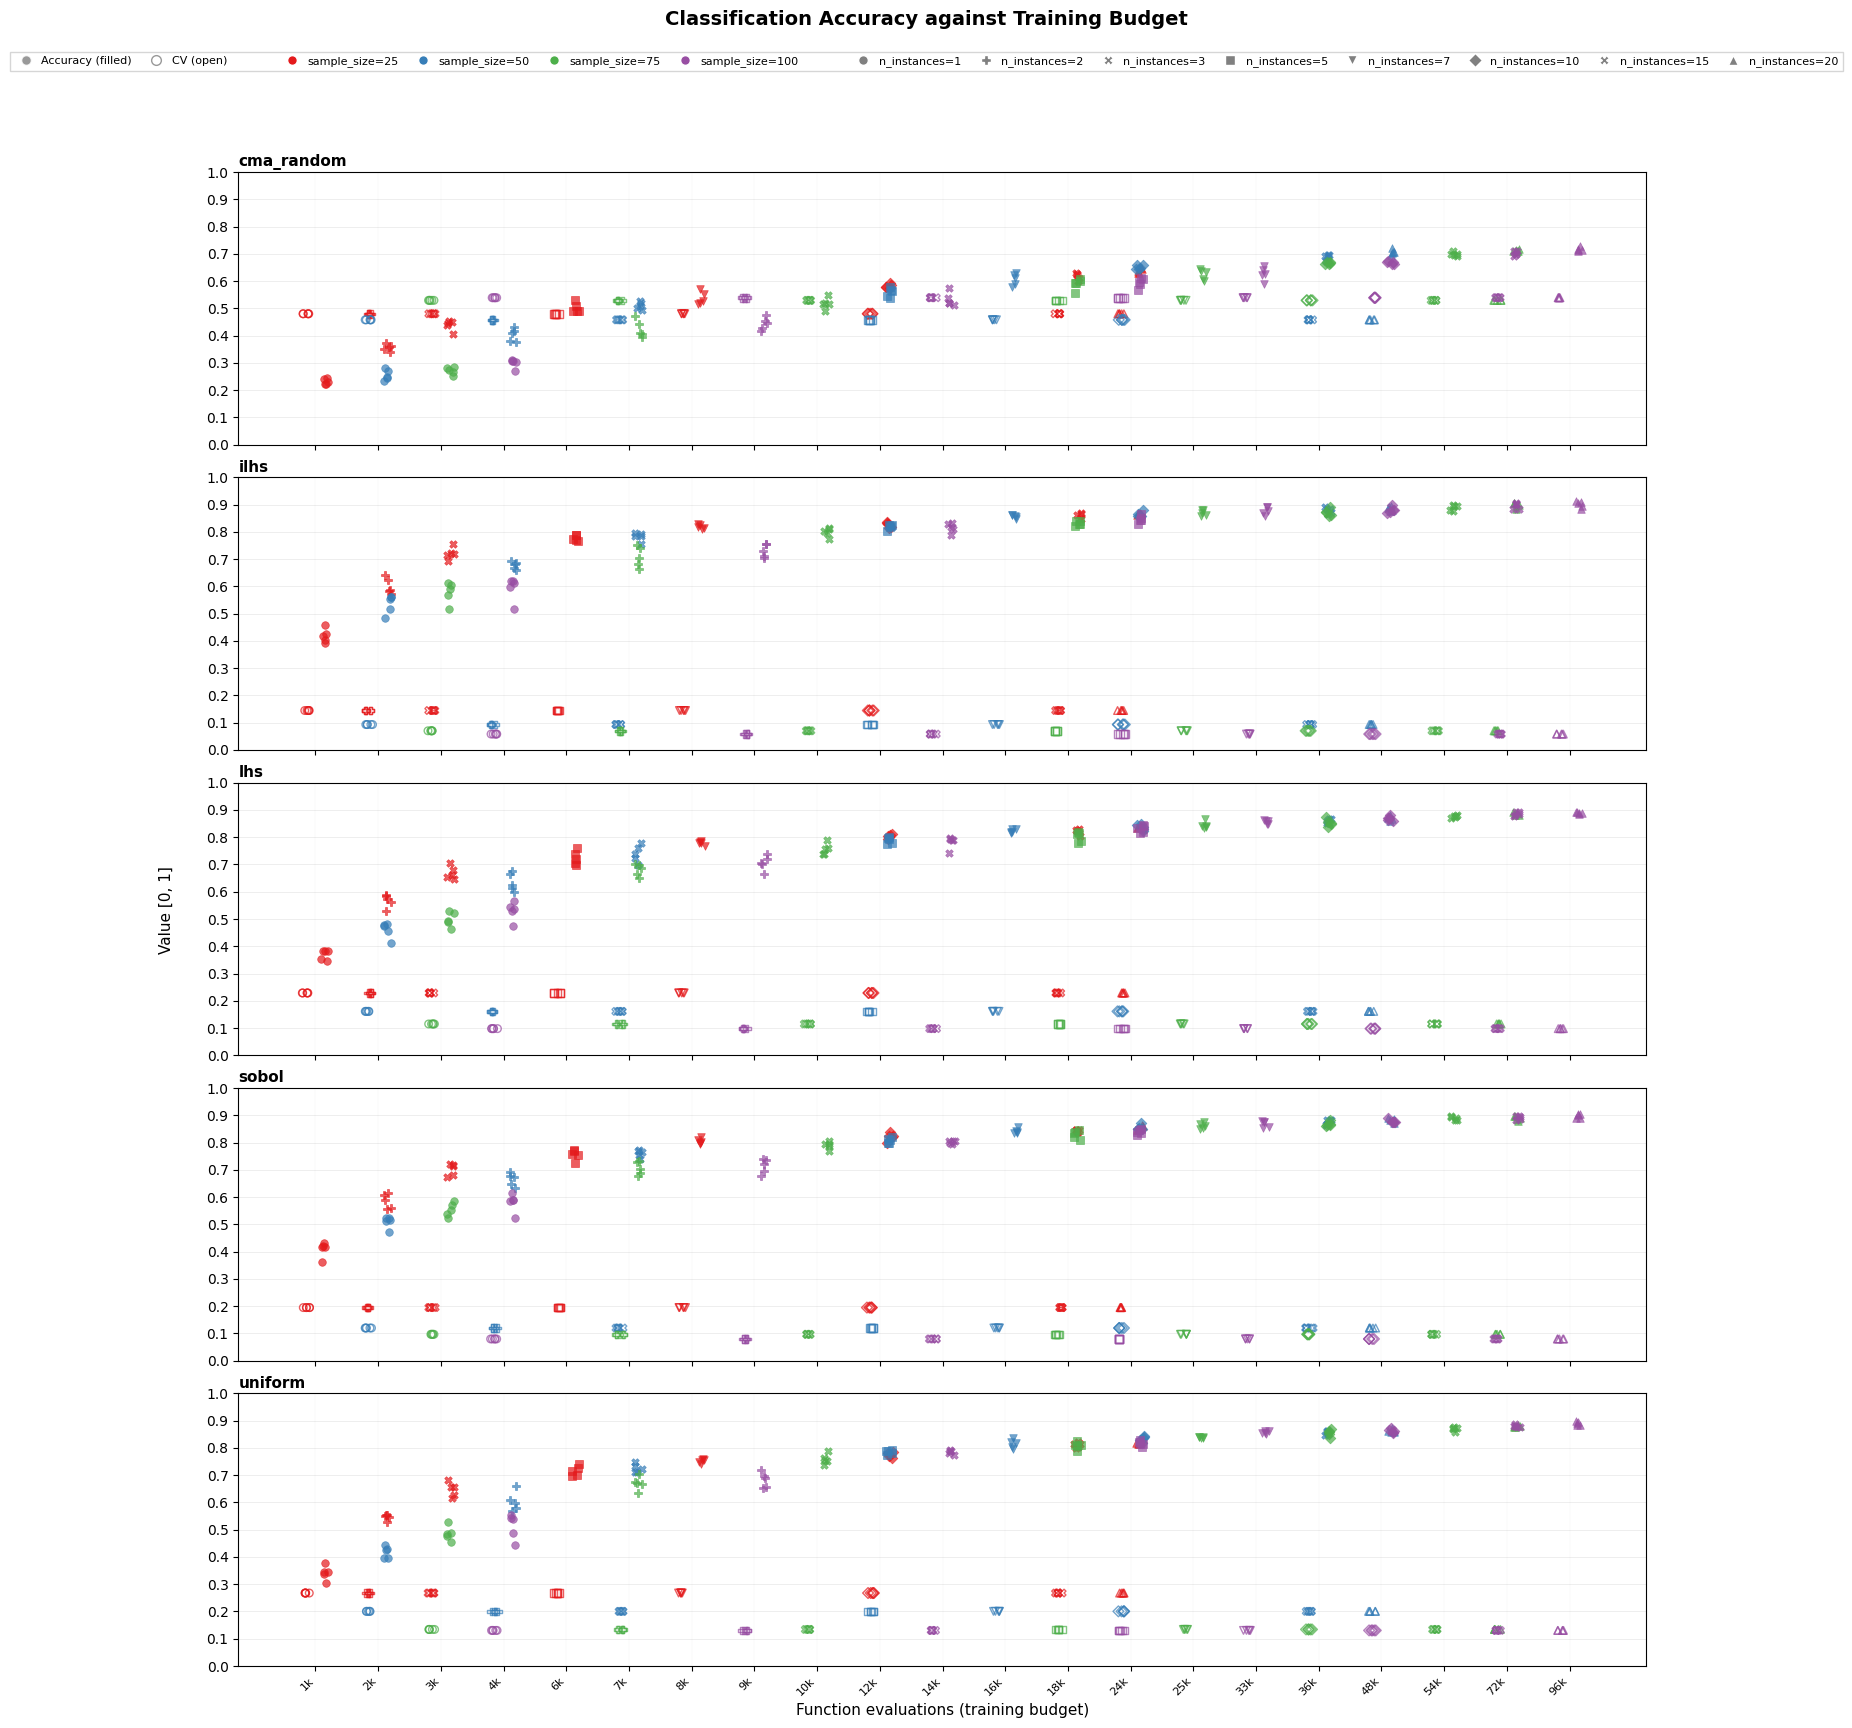

(<Figure size 1600x1800 with 5 Axes>,
 array([<Axes: title={'left': 'cma_random'}>,
        <Axes: title={'left': 'ilhs'}>, <Axes: title={'left': 'lhs'}>,
        <Axes: title={'left': 'sobol'}>,
        <Axes: title={'left': 'uniform'}, xlabel='Function evaluations (training budget)'>],
       dtype=object))

In [5]:
from ela_table_helper import *
plot_cv_vs_accuracy(df[df.n_runs_train == 1])


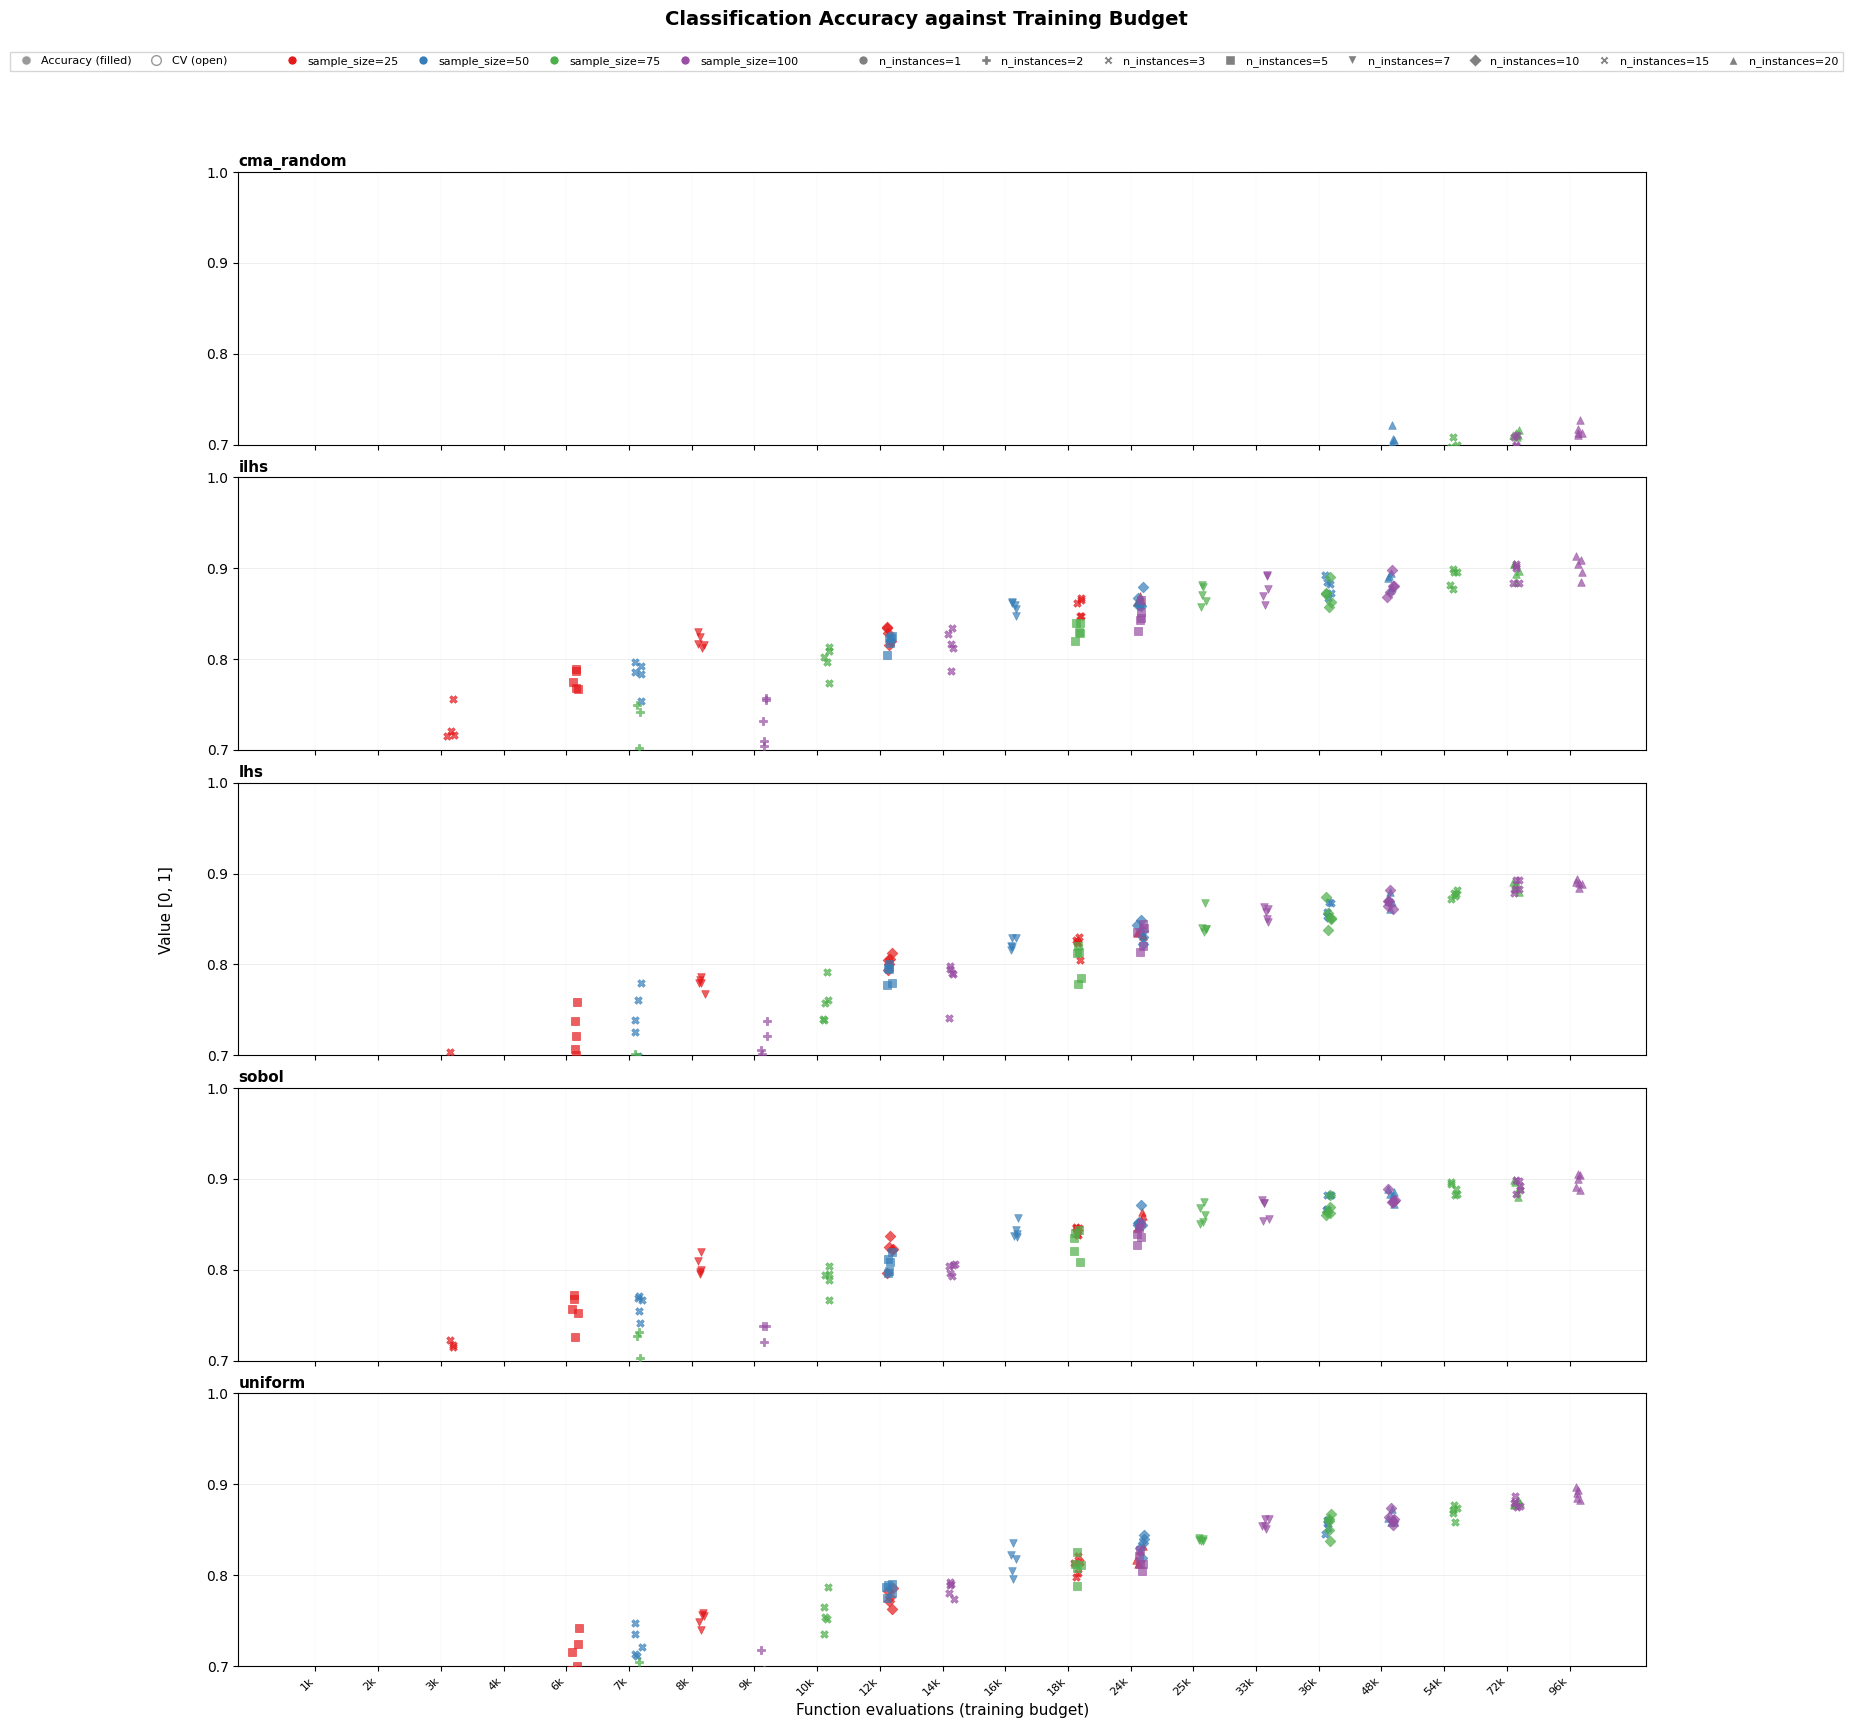

(<Figure size 1600x1800 with 5 Axes>,
 array([<Axes: title={'left': 'cma_random'}>,
        <Axes: title={'left': 'ilhs'}>, <Axes: title={'left': 'lhs'}>,
        <Axes: title={'left': 'sobol'}>,
        <Axes: title={'left': 'uniform'}, xlabel='Function evaluations (training budget)'>],
       dtype=object))

In [6]:
plot_cv_vs_accuracy(df[df.n_runs_train == 1], ylim=(0.7, 1.0))

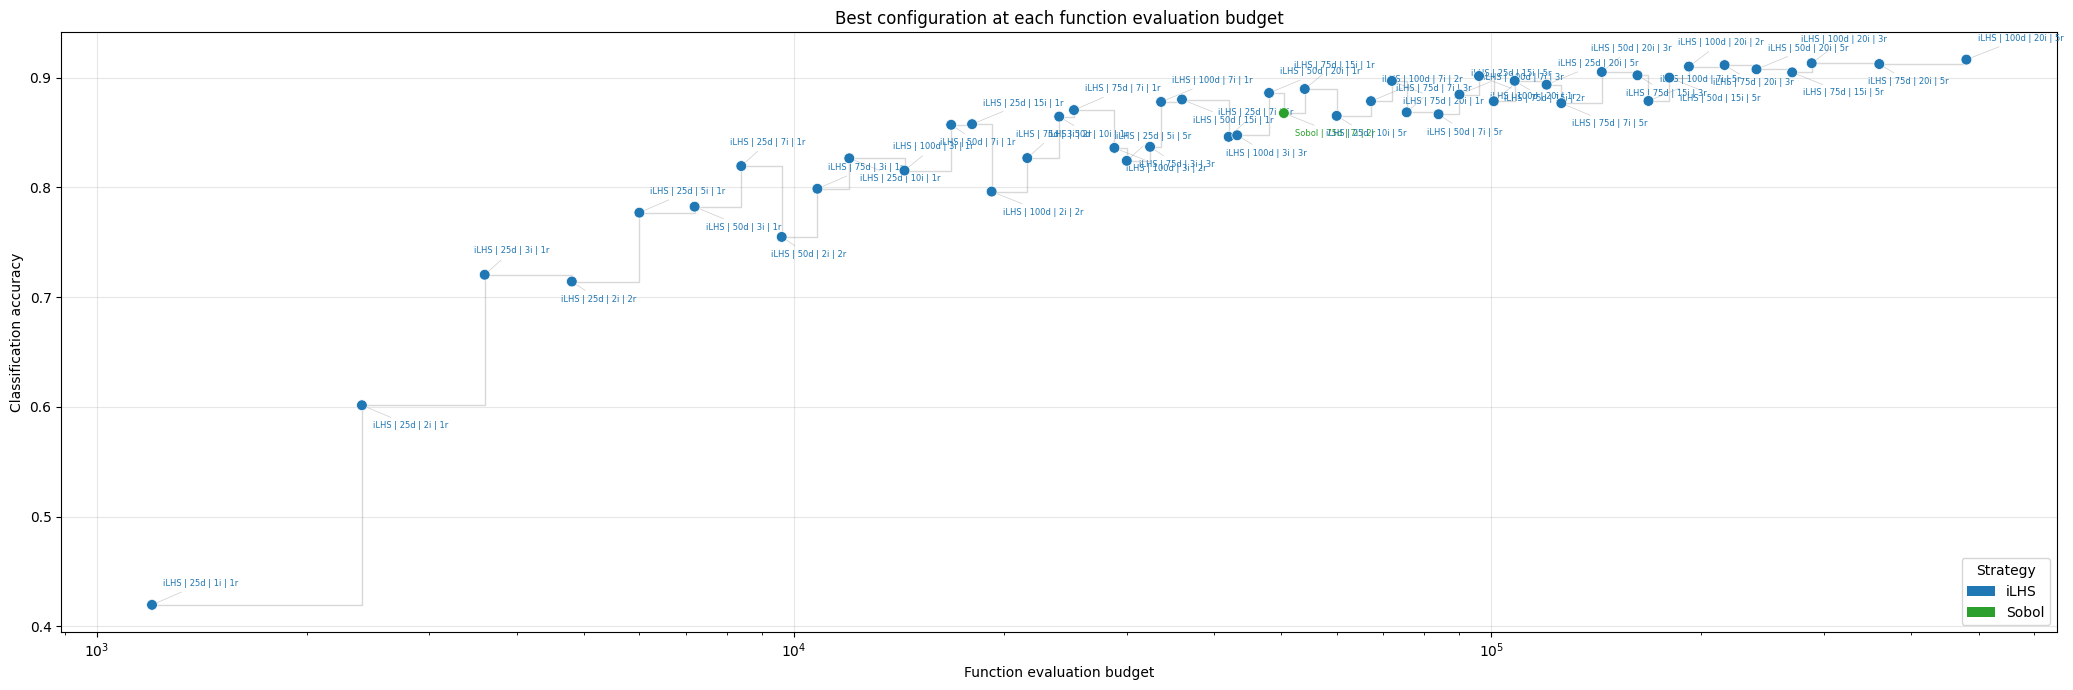

In [7]:
fig, best = plot_best_config_per_budget(
    fold_agg_df,
    target="acc_allruns_mean",
)
plt.show()

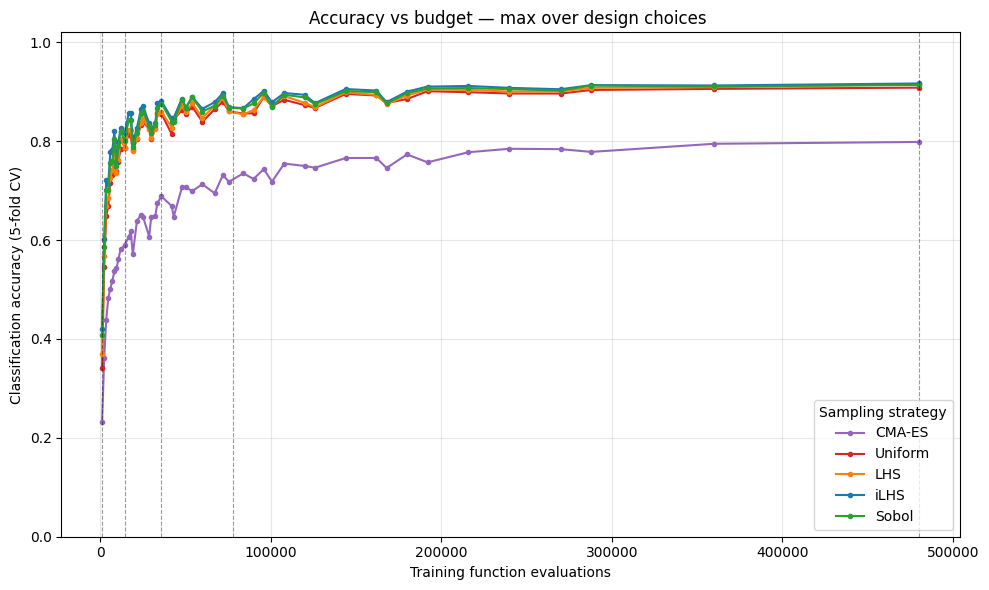

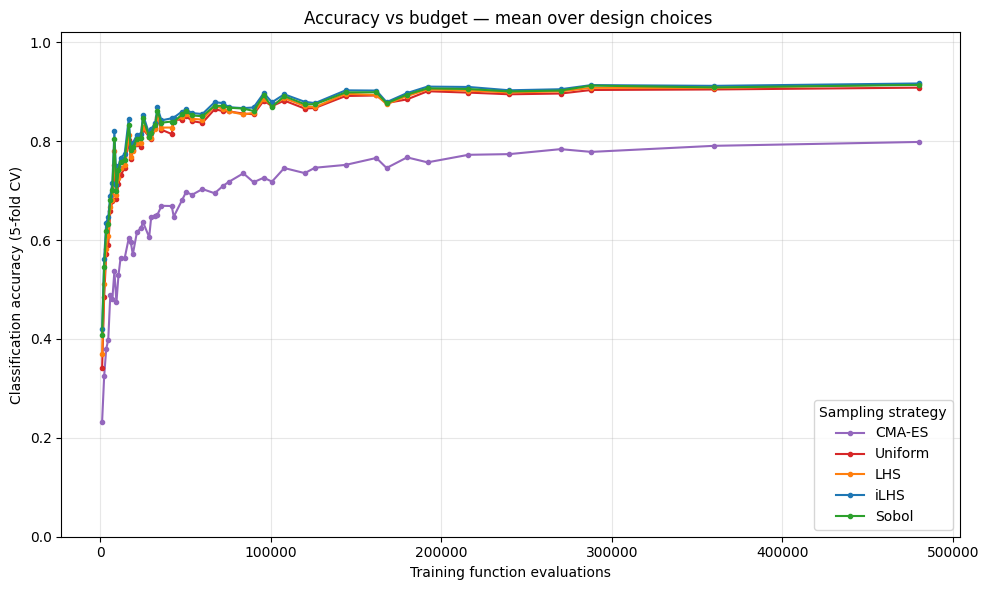

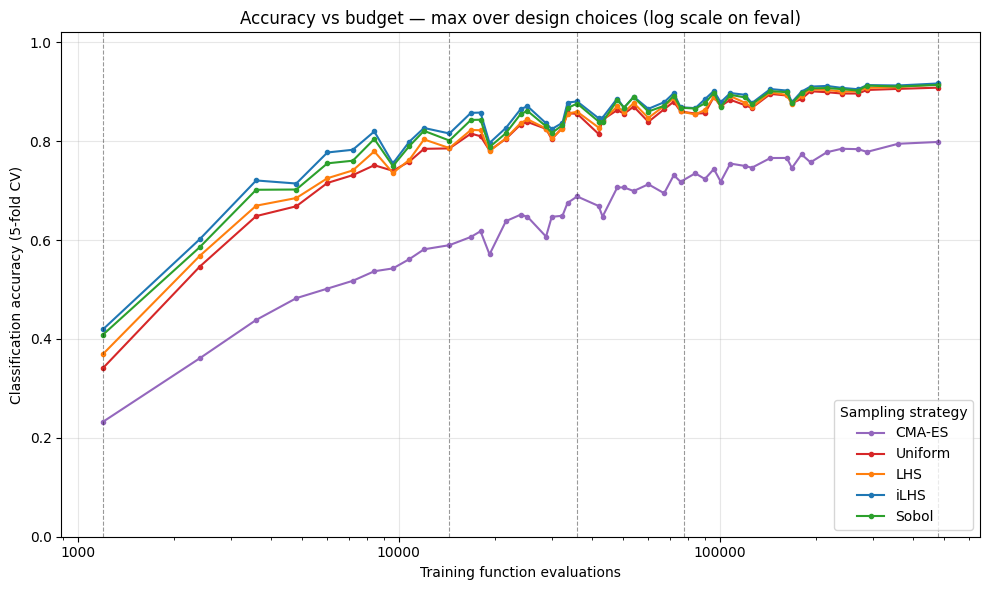

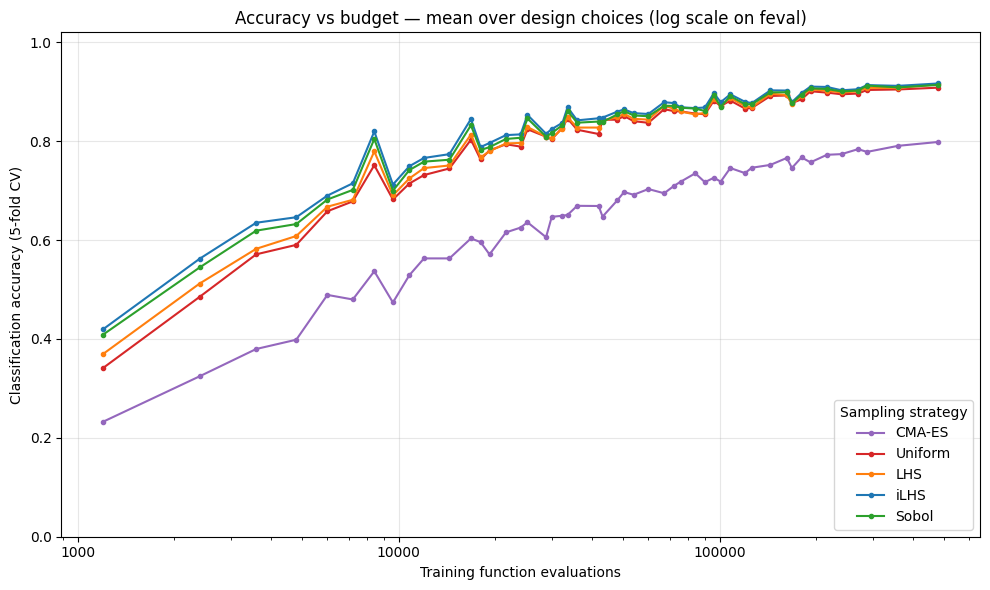

In [8]:
plot_accuracy_vs_budget(fold_agg_df, plot_bins=4)
plot_accuracy_vs_budget(fold_agg_df, agg_mode="mean")
plot_accuracy_vs_budget(fold_agg_df, plot_bins=4, log_scale=True)
plot_accuracy_vs_budget(fold_agg_df, agg_mode="mean", log_scale=True)

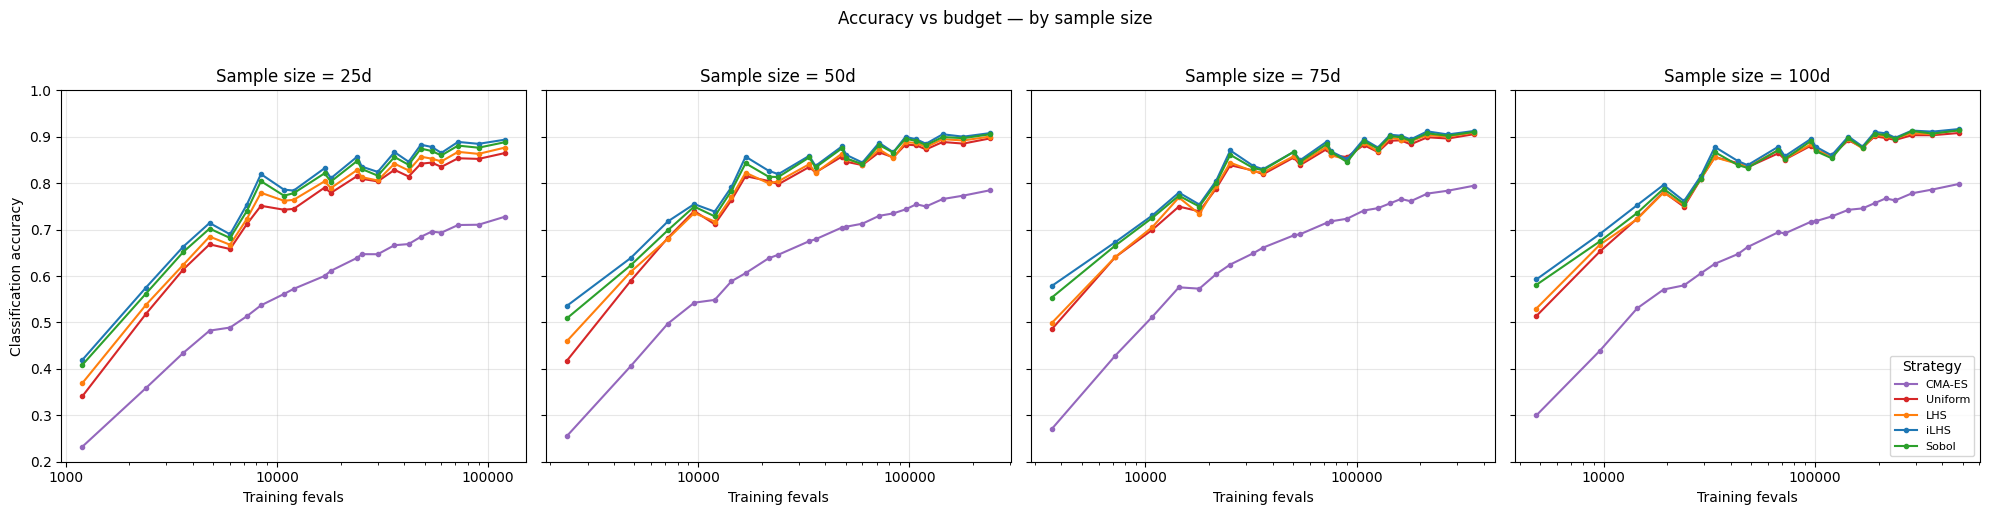

In [9]:
plot_accuracy_vs_budget_faceted(fold_agg_df, ylim = (0.2, 1.0))


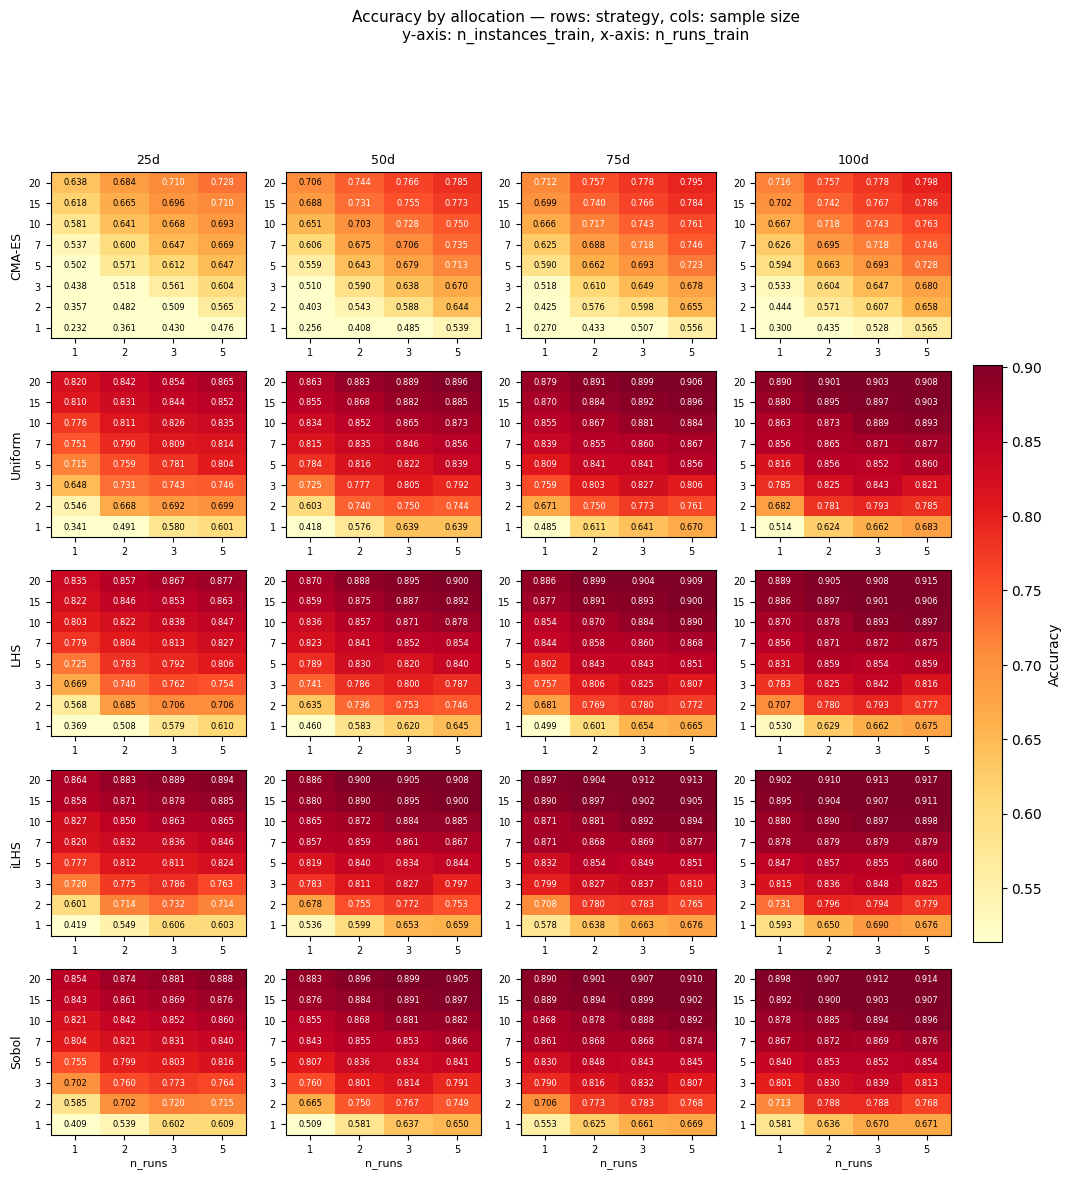

In [10]:
plot_allocation_heatmaps(fold_agg_df)


In [11]:
# from rq2_factor_importance import *
# imp_df = run_all(fold_agg_df, metric="acc_allruns_mean")

In [12]:
# from rq2_cv_accuracy import *
# run_all(fold_agg_df, cv_col="cv_instance_median_mean",
#                                acc_col="acc_allruns_mean")

Omitted strategies: cma_random
Remaining: ['ilhs', 'lhs', 'sobol', 'uniform']

Saturation curves for Strategy ...


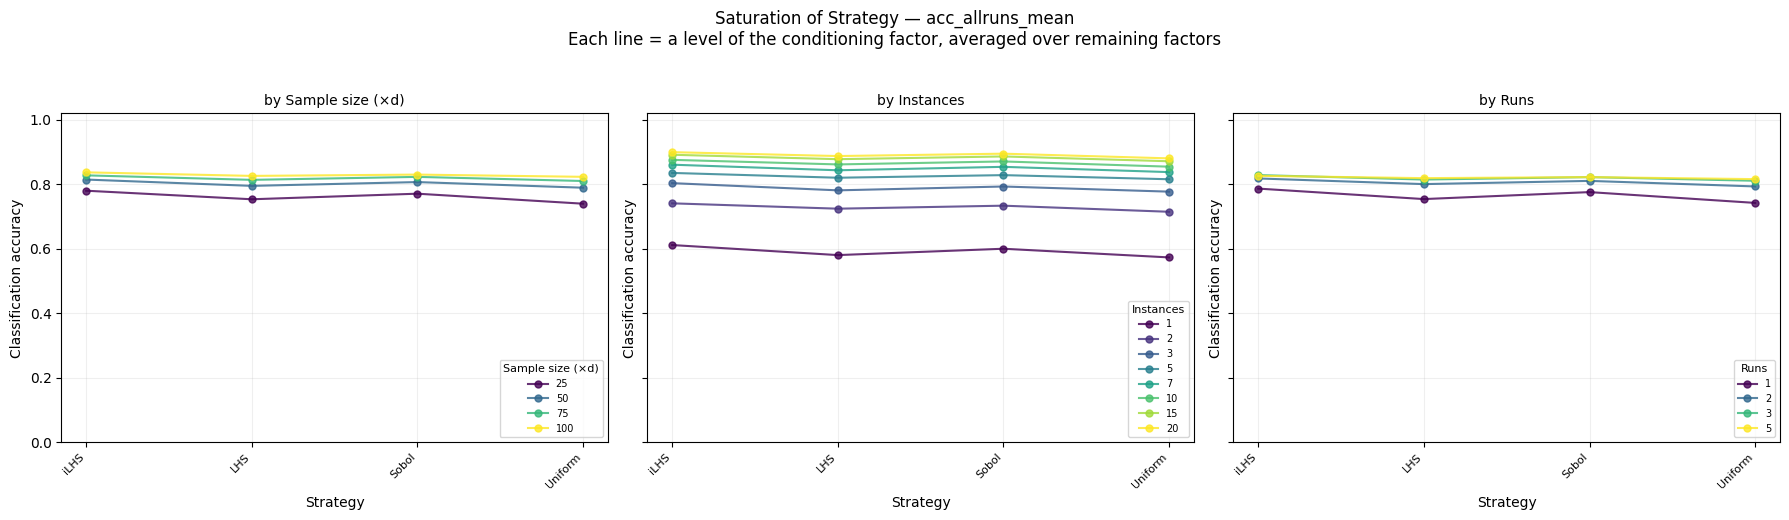

Saturation curves for Sample size (×d) ...


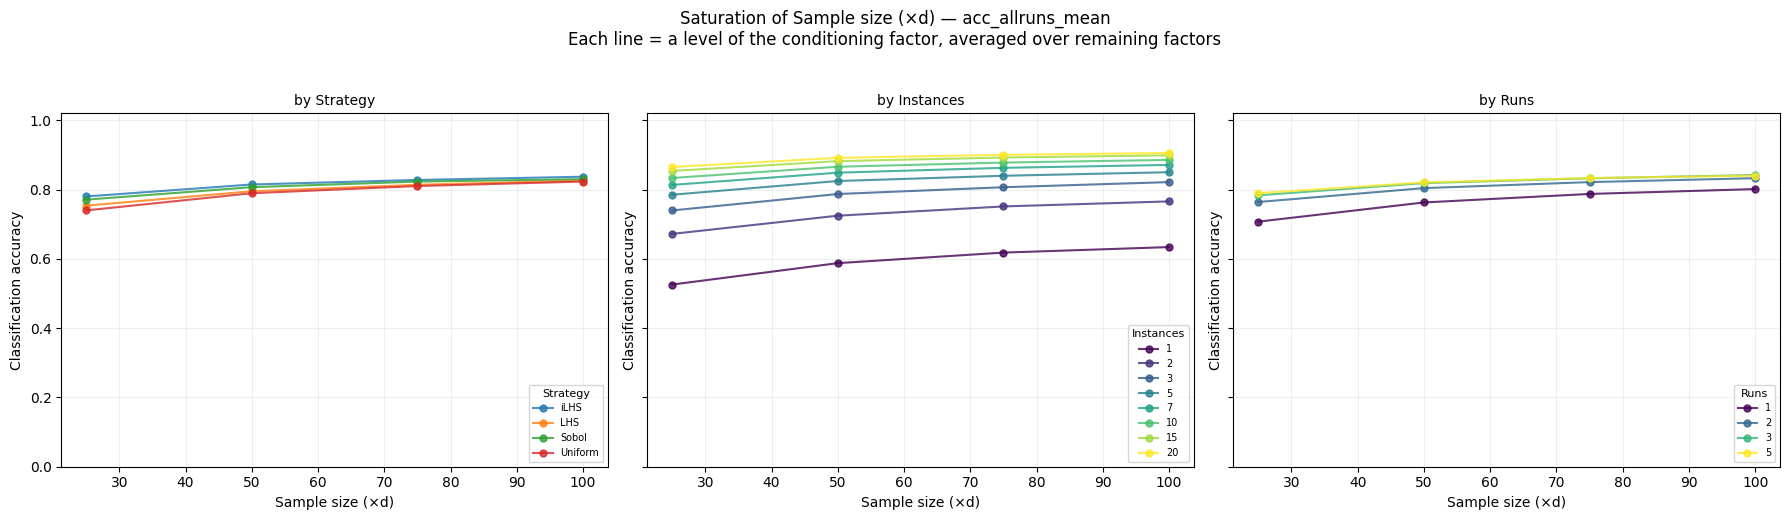

Saturation curves for Instances ...


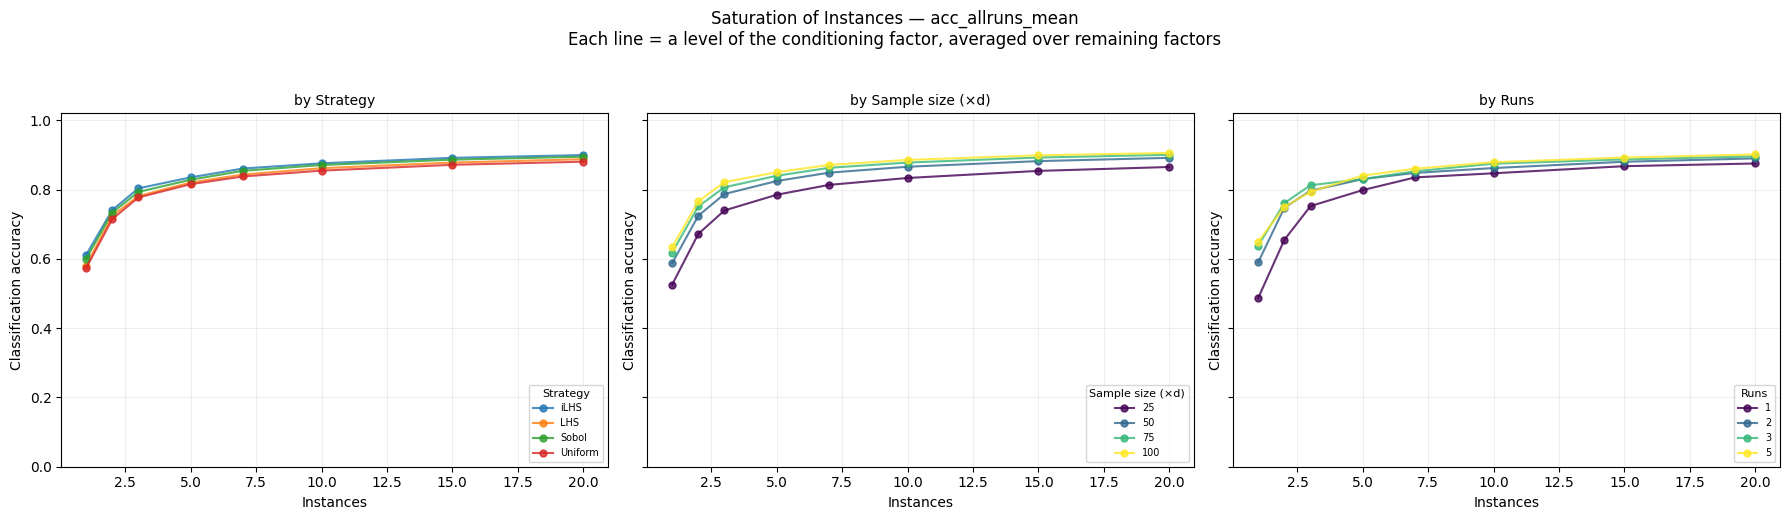

Saturation curves for Runs ...


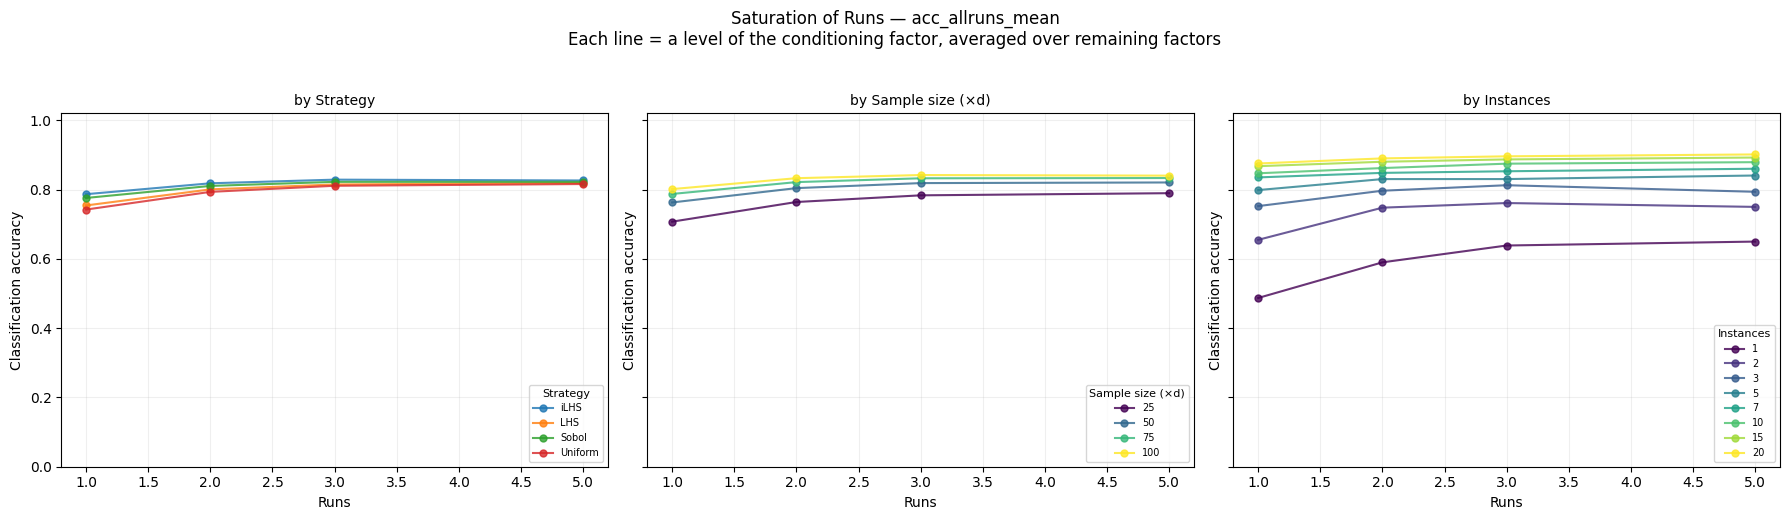

Marginal gains per step ...
          factor  from_level  to_level  mean_gain  total_gain  pct_of_total_gain
Sample size (×d)          25        50   0.040450    0.068005          59.481026
Sample size (×d)          50        75   0.017142    0.068005          25.207344
Sample size (×d)          75       100   0.010413    0.068005          15.311630
       Instances           1         2   0.137104    0.299313          45.806114
       Instances           2         3   0.060340    0.299313          20.159415
       Instances           3         5   0.036139    0.299313          12.074021
       Instances           5         7   0.024135    0.299313           8.063316
       Instances           7        10   0.016679    0.299313           5.572586
       Instances          10        15   0.016096    0.299313           5.377695
       Instances          15        20   0.008820    0.299313           2.946853
            Runs           1         2   0.040924    0.056166          72.863494


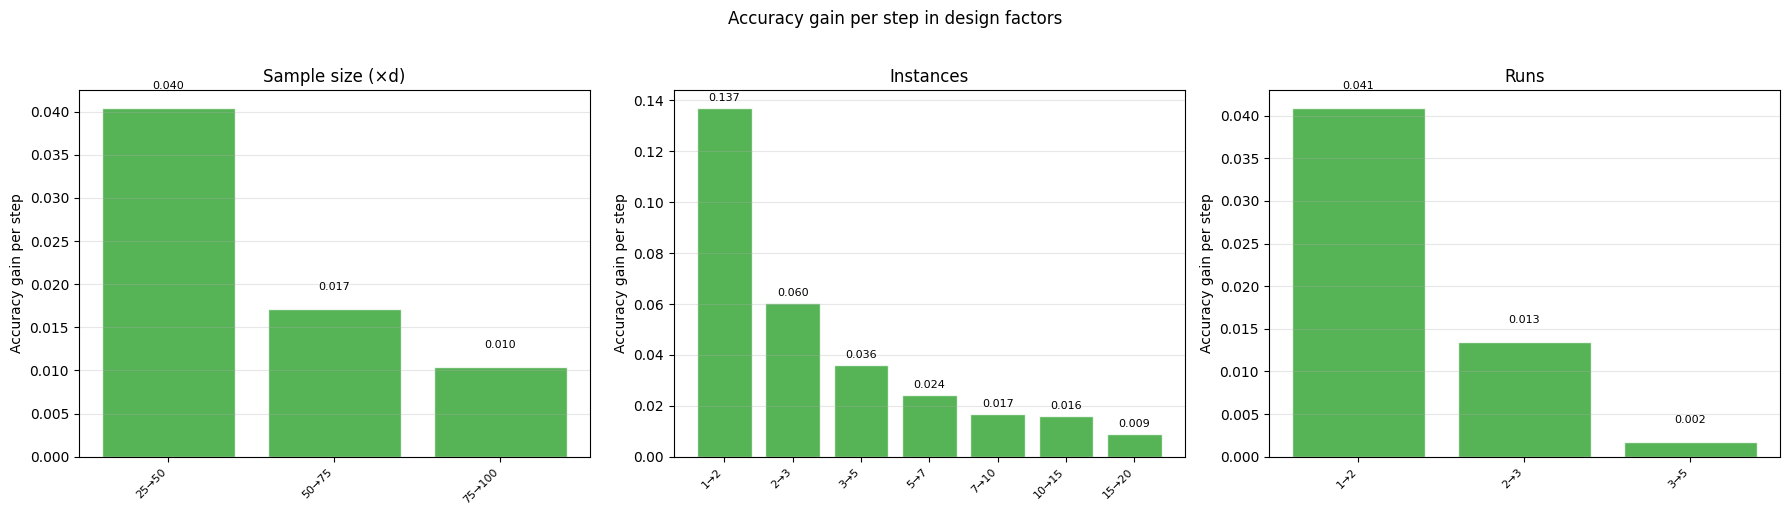

In [13]:
from rq2_saturation_curves import *

# All four factors + marginal gains table
gains_df = run_all(fold_agg_df, metric="acc_allruns_mean", omit_strategies="cma_random")

Omitted strategies: cma_random
Remaining: ['ilhs', 'lhs', 'sobol', 'uniform']

Overall saturation by tier: Strategy ...


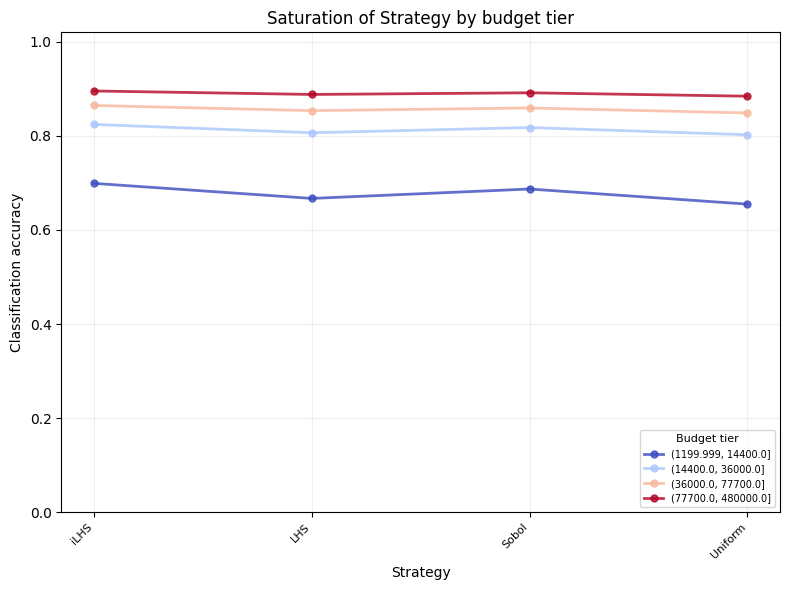

Overall saturation by tier: Sample size (×d) ...


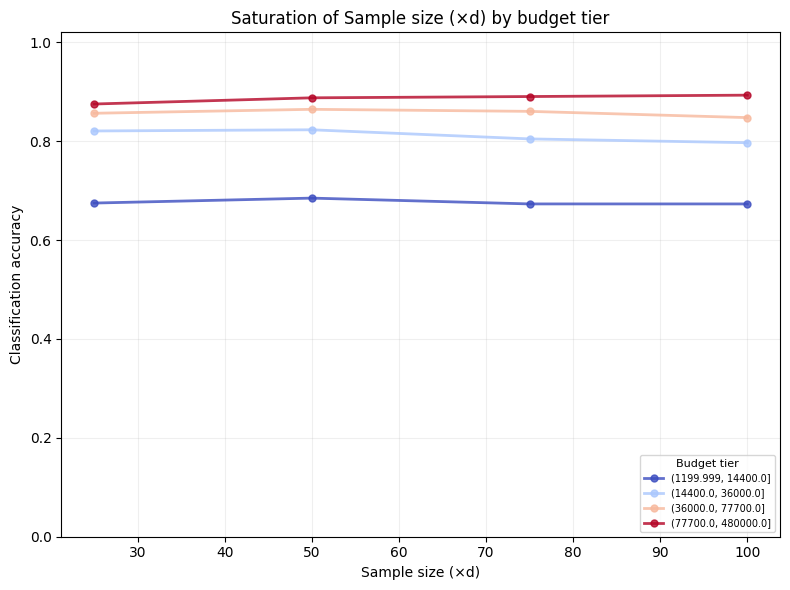

Overall saturation by tier: Instances ...


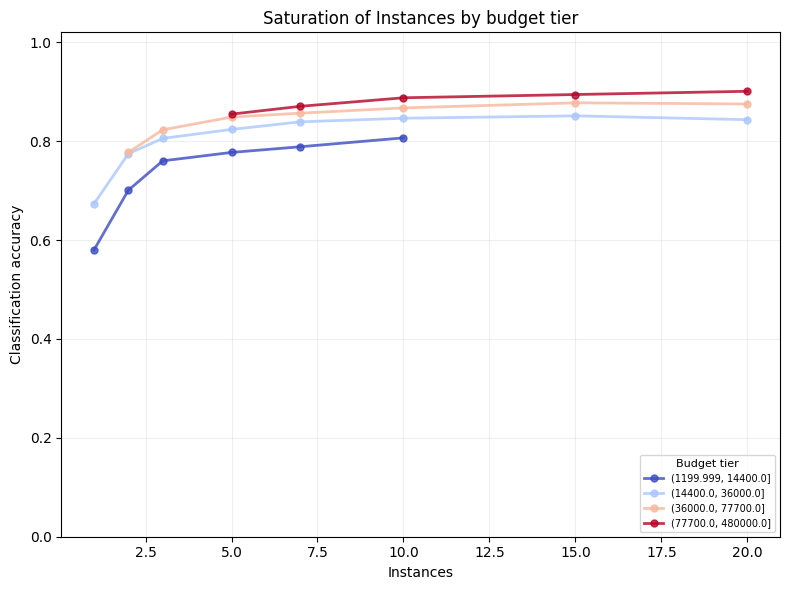

Overall saturation by tier: Runs ...


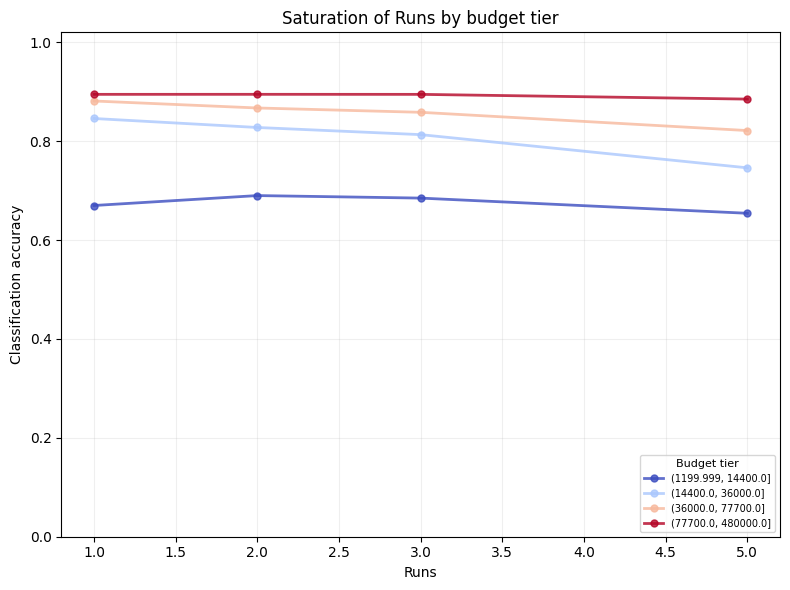

Per-tier saturation: Strategy ...


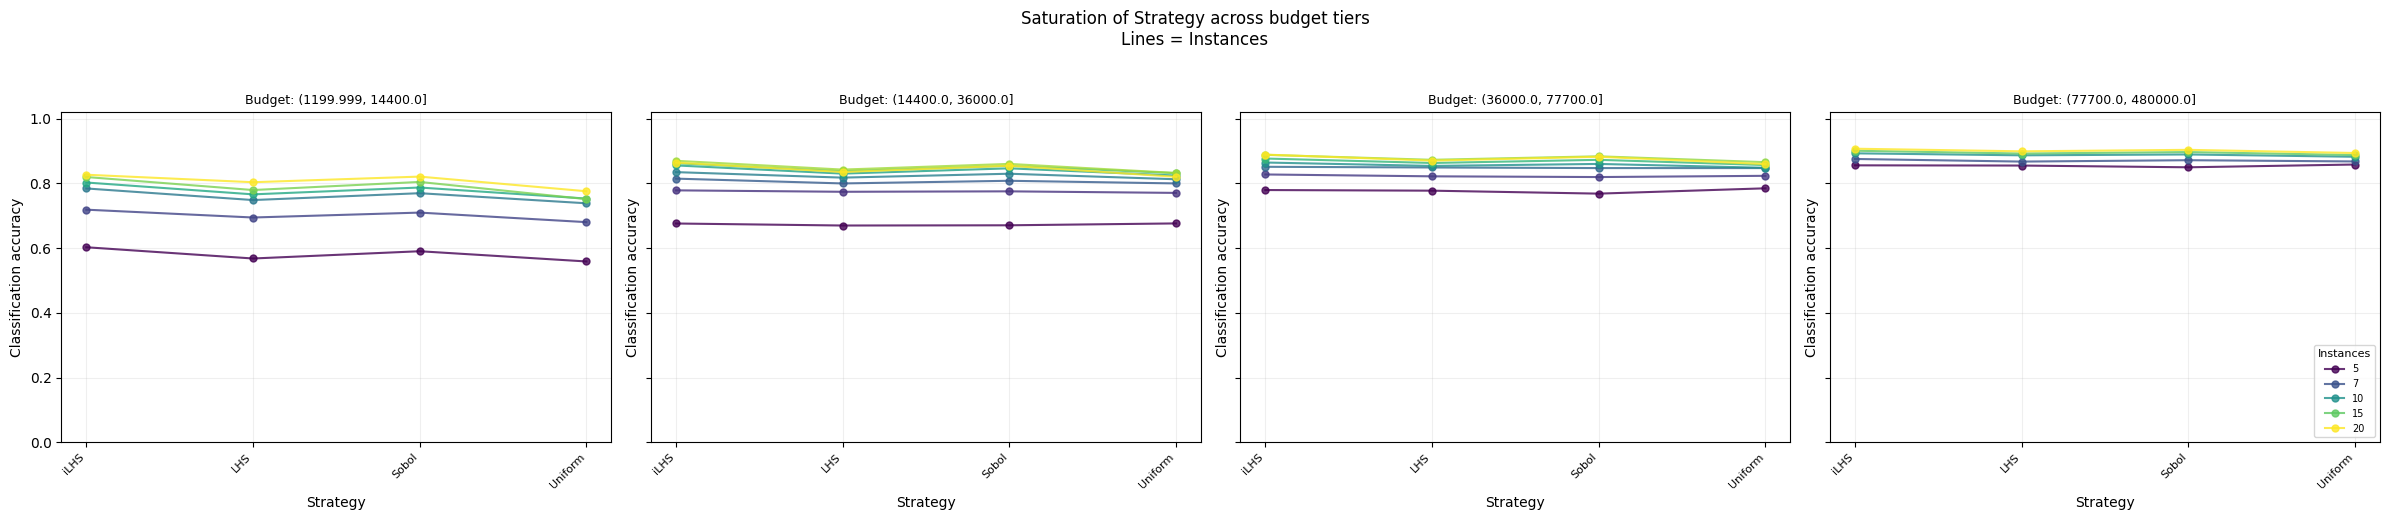

Per-tier saturation: Sample size (×d) ...


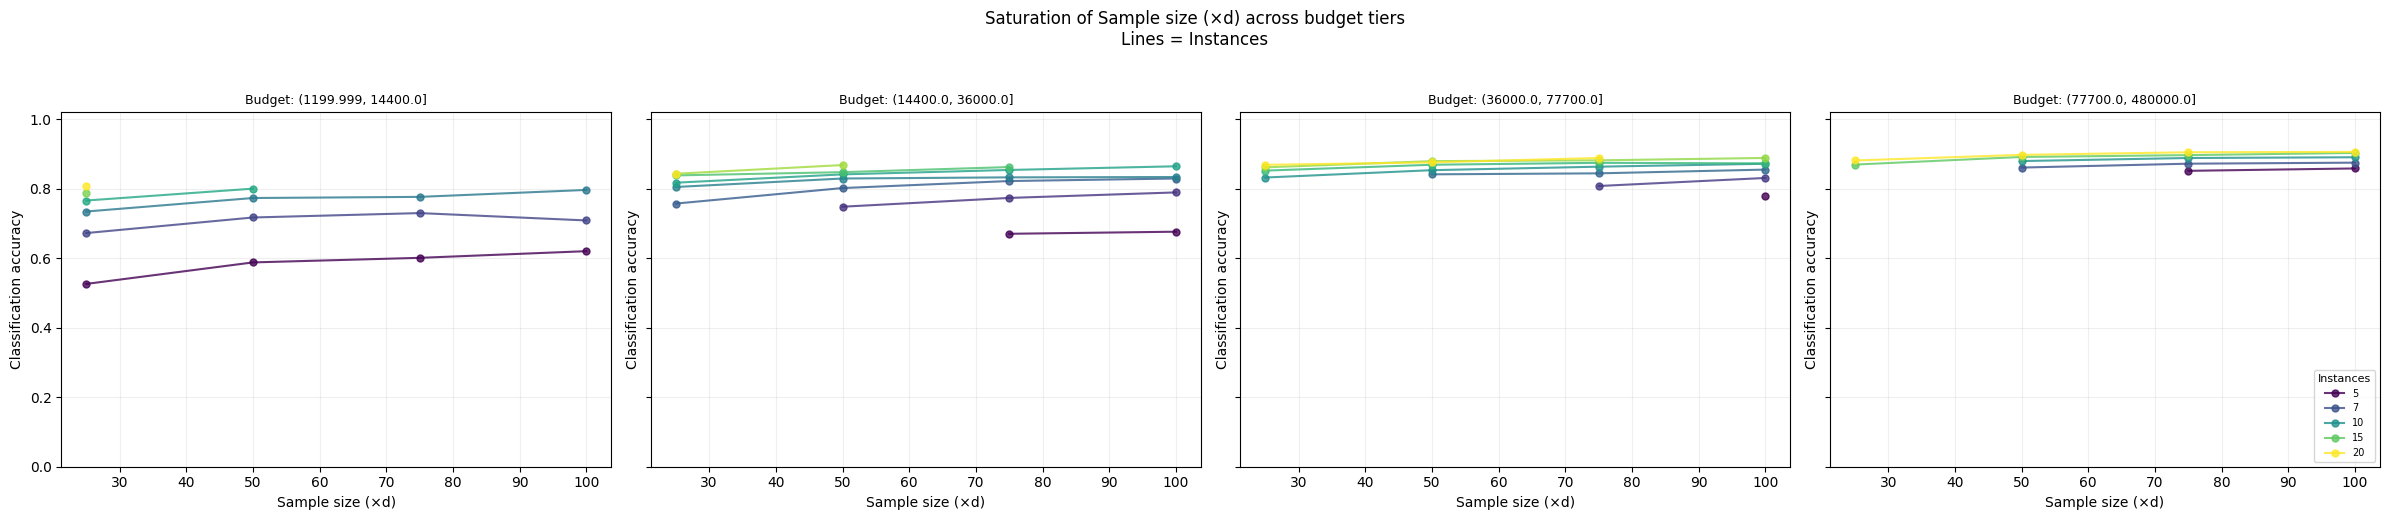

Per-tier saturation: Instances ...


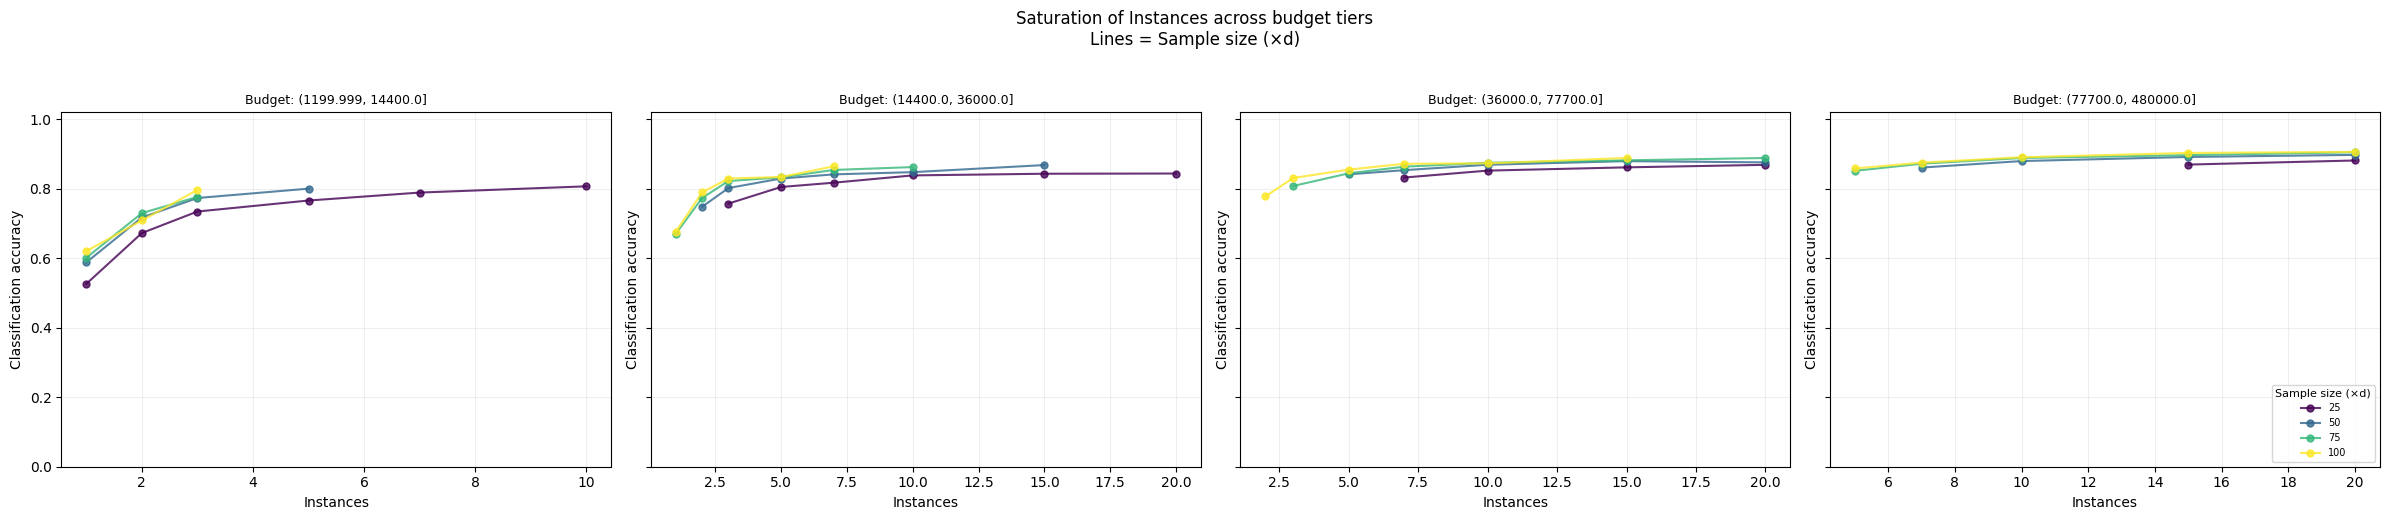

Per-tier saturation: Runs ...


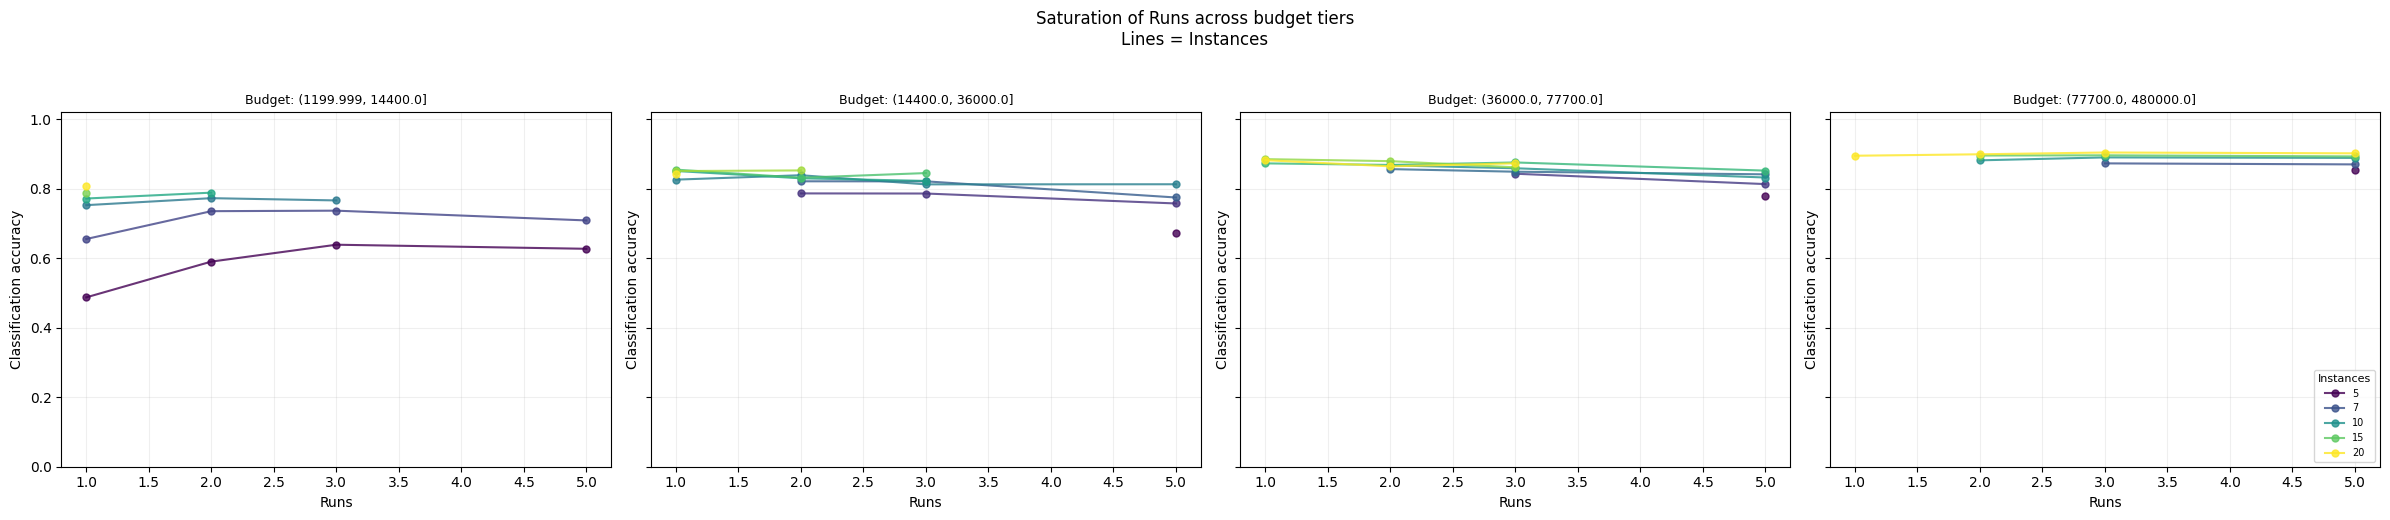

Marginal gains by tier ...
        budget_tier           factor  from_level  to_level  mean_gain  total_gain  pct_of_total_gain
(1199.999, 14400.0] Sample size (×d)          25        50   0.010000   -0.001786        -559.790074
(1199.999, 14400.0] Sample size (×d)          50        75  -0.011752   -0.001786         657.857652
(1199.999, 14400.0] Sample size (×d)          75       100  -0.000035   -0.001786           1.932422
(1199.999, 14400.0]        Instances           1         2   0.120906    0.226804          53.308443
(1199.999, 14400.0]        Instances           2         3   0.059400    0.226804          26.189847
(1199.999, 14400.0]        Instances           3         5   0.017031    0.226804           7.509028
(1199.999, 14400.0]        Instances           5         7   0.011471    0.226804           5.057834
(1199.999, 14400.0]        Instances           7        10   0.017997    0.226804           7.934848
(1199.999, 14400.0]             Runs           1         2   0.0

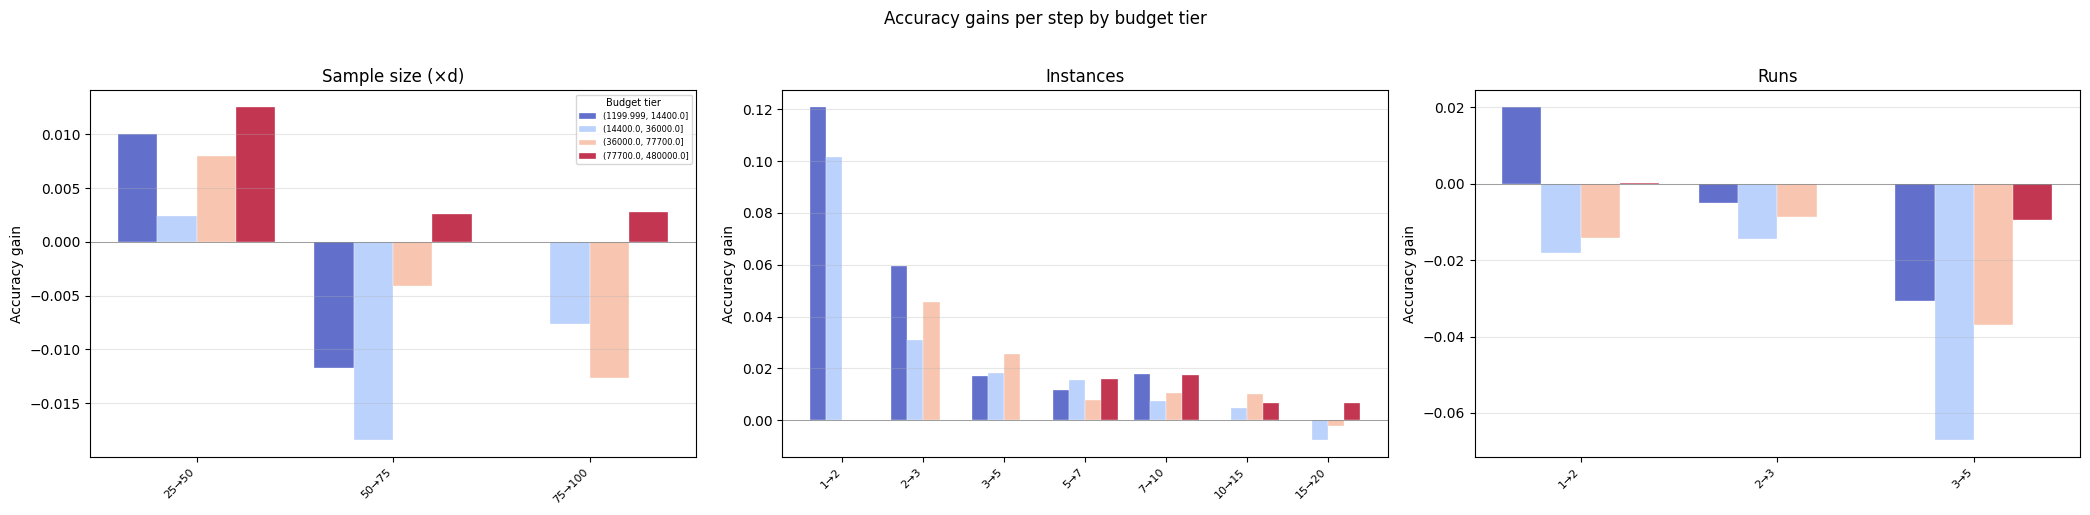

In [14]:
gains_by_tier = run_by_tier(fold_agg_df, metric="acc_allruns_mean",
                             omit_strategies="cma_random", n_tiers=4)

In [15]:
from rq2_fanova_stratified import *

df_d2 = fold_agg_df[fold_agg_df["dimension"] == 2][fold_agg_df["sampling_strategy"] != "cma_random"].copy()

results, summary, interactions = run_stratified_fanova(
    df_d2,
    hyperparams=["sample_size_per_dim", "sampling_strategy",
                 "n_instances_train", "n_runs_train"],
    target="acc_allruns_mean",
    budget_col="n_feval_train",
    n_budget_tiers=4,
)

In [16]:
results

,hyperparameter,importance_mean,importance_std,importance_raw,rank,rf_oob_r2,budget_tier,n_samples,budget_range_low,budget_range_high
0,n_instances_train,1.726367,0.079260,"[1.5872980752304708, 1.7049555123194136, 1.699...",1,NaN,ALL,512,1200.0,480000.0
1,n_runs_train,0.177579,0.012564,"[0.15933680979884624, 0.2091838749147179, 0.18...",2,NaN,ALL,512,1200.0,480000.0
2,sample_size_per_dim,0.149096,0.007656,"[0.14808189881434575, 0.13021504188249333, 0.1...",3,NaN,ALL,512,1200.0,480000.0
3,sampling_strategy,0.020227,0.001883,"[0.021431476775097047, 0.018884789439997385, 0...",4,NaN,ALL,512,1200.0,480000.0
4,n_instances_train,2.291564,0.153865,"[2.0861189731771983, 2.4366452022403546, 2.131...",1,NaN,Q1,144,1200.0,14400.0
5,n_runs_train,0.551523,0.069968,"[0.6046599504102496, 0.522653559482068, 0.6756...",2,NaN,Q1,144,1200.0,14400.0
6,sample_size_per_dim,0.299904,0.024650,"[0.30046291001312375, 0.27618020860578185, 0.3...",3,NaN,Q1,144,1200.0,14400.0
7,sampling_strategy,0.051165,0.008526,"[0.046903210042065324, 0.06594935006507507, 0....",4,NaN,Q1,144,1200.0,14400.0
8,n_instances_train,1.508937,0.134937,"[1.4781380892288345, 1.5630305300574947, 1.698...",1,NaN,Q2,136,14400.0,36000.0
9,sample_size_per_dim,0.131294,0.012568,"[0.11788751442759693, 0.13840748276749337, 0.1...",2,NaN,Q2,136,14400.0,36000.0


In [17]:
summary

hyperparameter,n_instances_train,n_runs_train,sample_size_per_dim,sampling_strategy
budget_tier,,,,
ALL,1.726367,0.177579,0.149096,0.020227
Q1,2.291564,0.551523,0.299904,0.051165
Q2,1.508937,0.105822,0.131294,0.083691
Q3,0.710718,0.455288,0.080624,0.139870
Q4,1.762621,0.111801,0.479187,0.142531


In [18]:
interactions

,pair,hp_i,hp_j,joint_importance_mean,joint_importance_std,individual_sum,interaction_strength,budget_tier
0,n_instances_train × n_runs_train,n_instances_train,n_runs_train,1.829109,0.095142,1.903946,-0.074838,ALL
1,sampling_strategy × n_instances_train,sampling_strategy,n_instances_train,1.730098,0.106164,1.746594,-0.016496,ALL
2,sample_size_per_dim × n_runs_train,sample_size_per_dim,n_runs_train,0.311776,0.024106,0.326675,-0.014899,ALL
3,sample_size_per_dim × n_instances_train,sample_size_per_dim,n_instances_train,1.864448,0.106663,1.875463,-0.011015,ALL
4,sampling_strategy × n_runs_train,sampling_strategy,n_runs_train,0.188704,0.019932,0.197806,-0.009101,ALL
5,sample_size_per_dim × sampling_strategy,sample_size_per_dim,sampling_strategy,0.161315,0.007987,0.169322,-0.008007,ALL
6,n_instances_train × n_runs_train,n_instances_train,n_runs_train,2.080040,0.224903,2.843087,-0.763047,Q1
7,sample_size_per_dim × n_instances_train,sample_size_per_dim,n_instances_train,2.104270,0.249277,2.591468,-0.487197,Q1
8,sample_size_per_dim × n_runs_train,sample_size_per_dim,n_runs_train,0.769361,0.069784,0.851427,-0.082067,Q1
9,sampling_strategy × n_instances_train,sampling_strategy,n_instances_train,2.315612,0.297438,2.342729,-0.027117,Q1


In [19]:
from rq2_rf_impurity_importance import *
df_d2 = fold_agg_df[fold_agg_df["dimension"] == 2][fold_agg_df["sampling_strategy"] != "cma_random"].copy()
results_imp, summary_imp, metrics_df = run_stratified_impurity_importance(
    df_d2,
    hyperparams=["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"],
    target="acc_allruns_mean",
    budget_col="n_feval_train",
    n_budget_tiers=4,
)

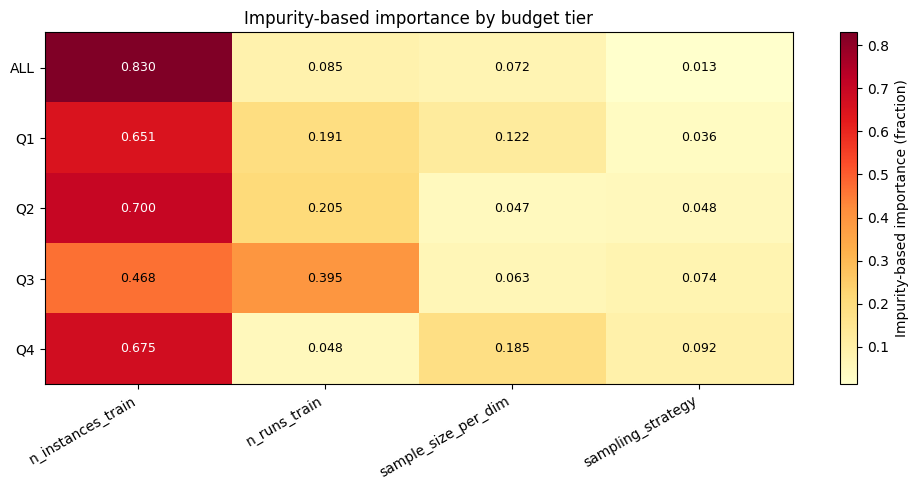

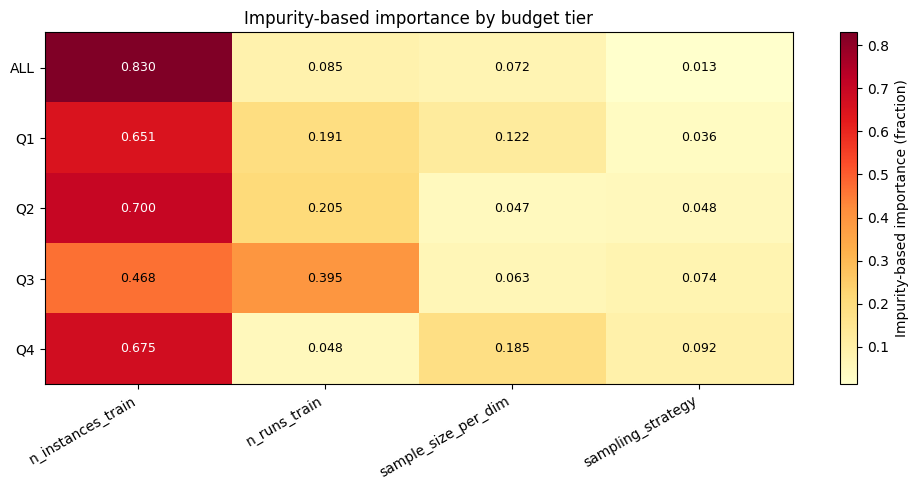

In [20]:
plot_importance_heatmap(summary_imp)


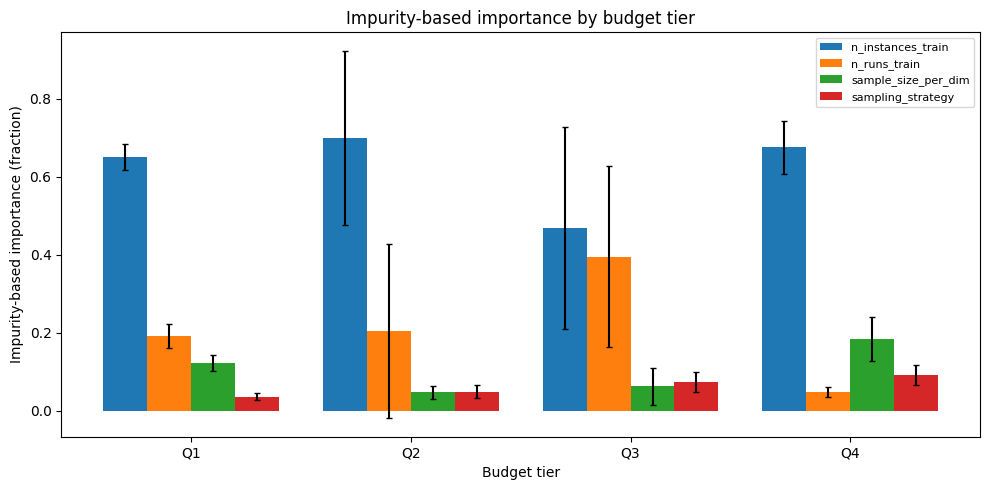

In [21]:
plot_importance_bars(results_imp)
plt.show()


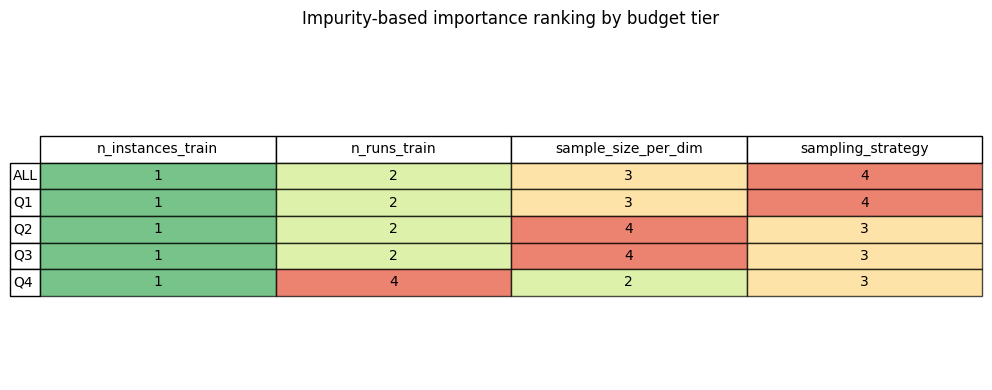

In [22]:
plot_rank_table(results_imp)
plt.show()

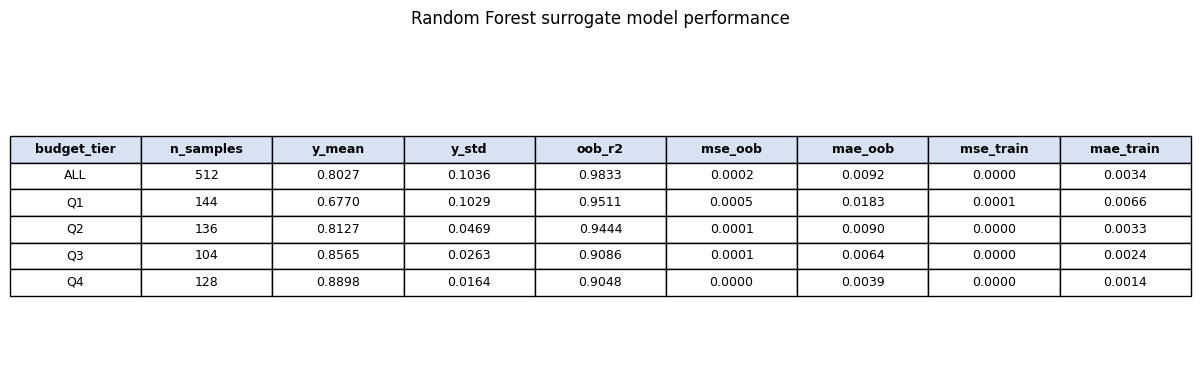

In [23]:
plot_metrics_table(metrics_df)
plt.show()


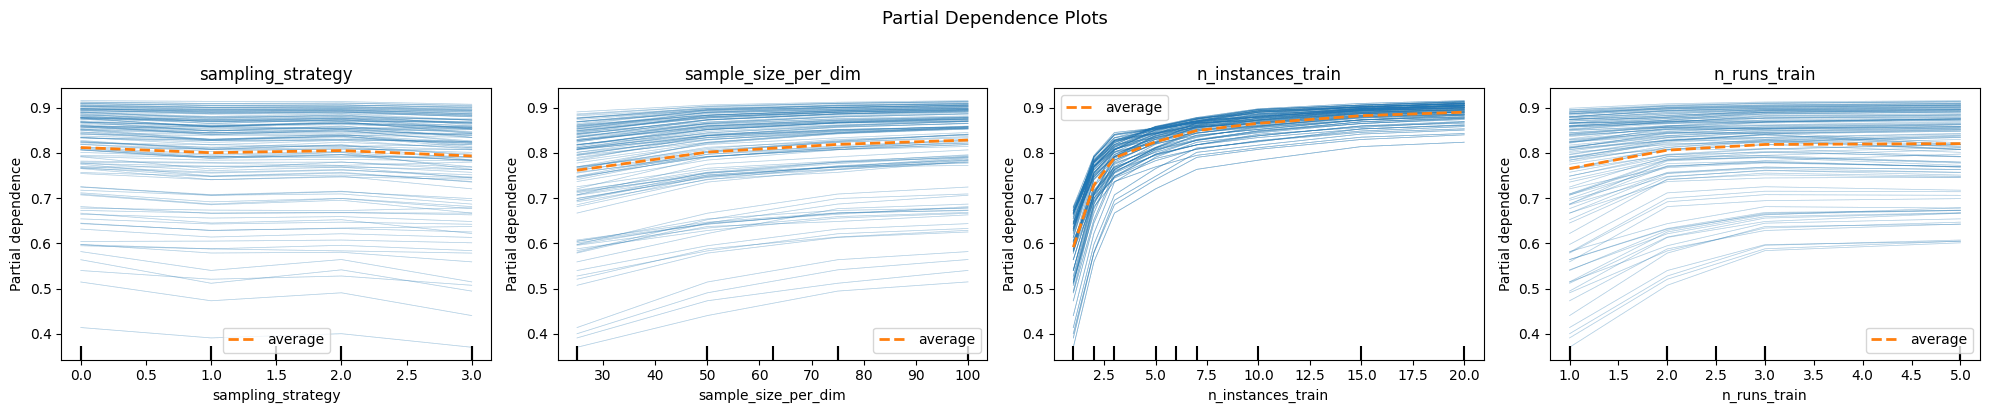

In [24]:
plot_pdp_individual(df_d2, ["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"], target="acc_allruns_mean")
plt.show()


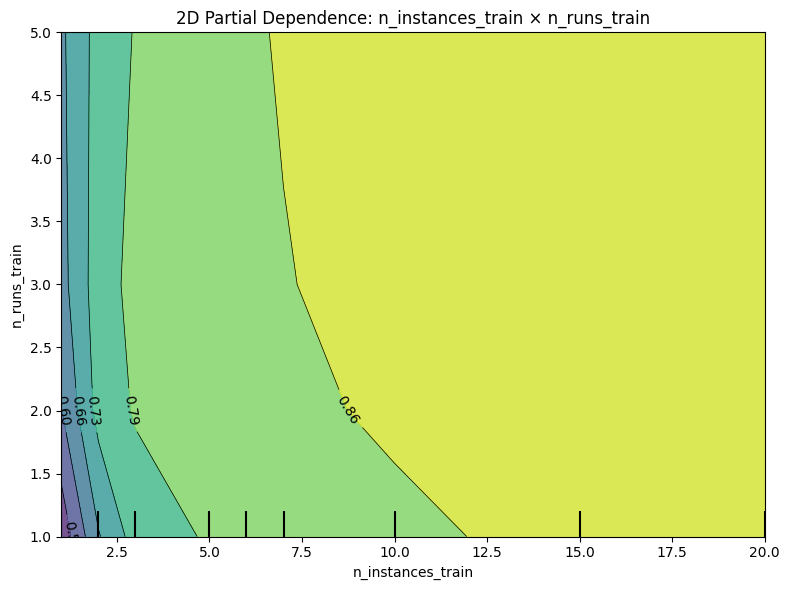

In [25]:
plot_pdp_2d(df_d2, ["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"],
            feature_pair=("n_instances_train", "n_runs_train"),
            target="acc_allruns_mean")
plt.show()

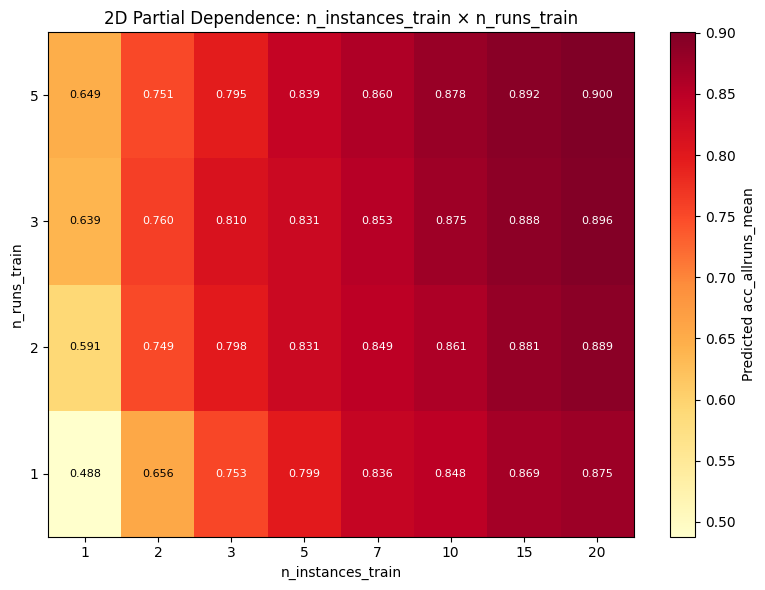

In [26]:
plot_pdp_2d_heatmap(df_d2, ["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"],
            feature_pair=("n_instances_train", "n_runs_train"),
            target="acc_allruns_mean",
            annotate=True)
plt.show()

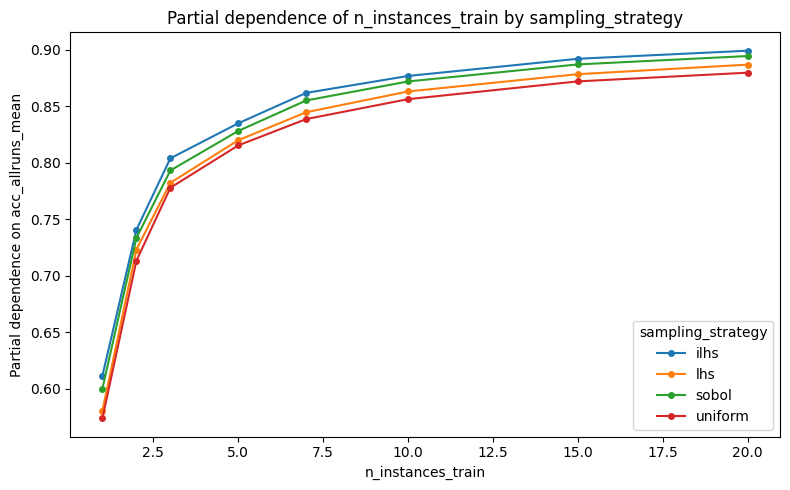

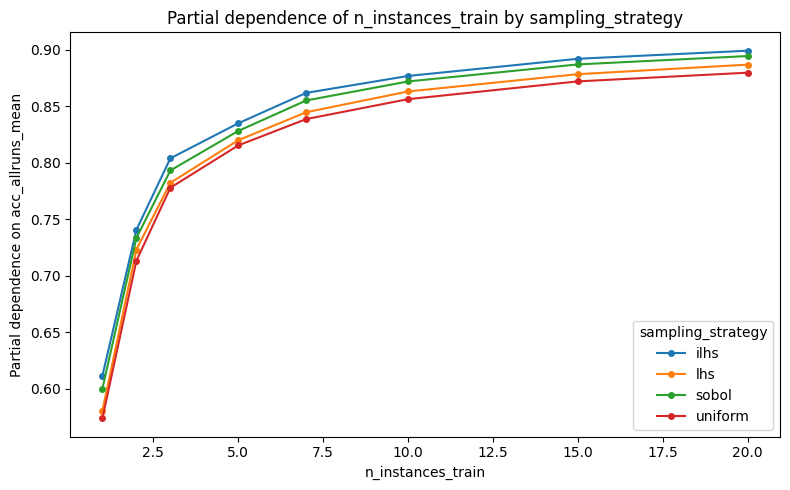

In [27]:
plot_pdp_by_strategy(df_d2, ["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"], feature="n_instances_train")


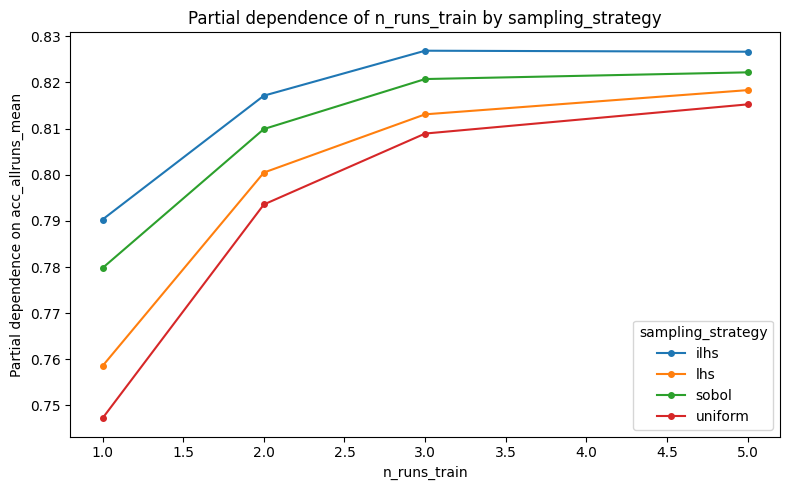

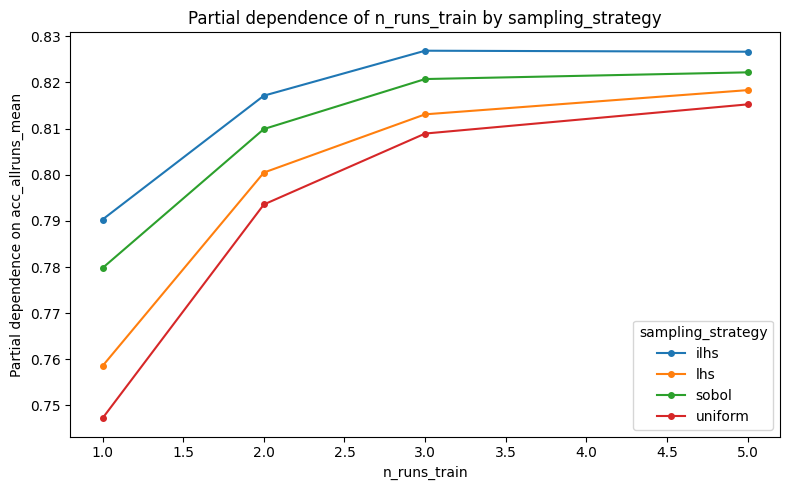

In [28]:
plot_pdp_by_strategy(df_d2, ["sampling_strategy", "sample_size_per_dim",
                 "n_instances_train", "n_runs_train"], feature="n_runs_train")